In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

# Get data from arrayExpress

In [3]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16433"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,

)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16433 in: ../data_arrayExpress/E-MTAB-16433
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16433
      Inferred 1 dataset representation: SG (full prefix: treatment_HD4246_SG)
      Selected dataset for in-memory loading: SG (full prefix: treatment_HD4246_SG)
[3/3] Preparing selected dataset.
      Loading selected dataset from disk: E-MTAB-16433/E-MTAB-16433_SG.h5ad


AnnData object with n_obs × n_vars = 7330 × 25470
    obs: 'sample_id', 'library_id', 'treatment', 'mouse_ID', 'batch', 'leiden'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## Gene set activation scores

In [4]:
# Import literature gene sets to adata
from utils import get_gene_sets
print("Importing gene sets into anndata object...")
adata = get_gene_sets(adata, verbose=False)

Importing gene sets into anndata object...


In [5]:
# Compute gene set scores
import utils_genelist as genelist

gs_process = ['score_YAP', 'score_fetal', 'score_Lgr5', 'score_epiHR']

gene_sets = adata.uns['gene_sets']
for score_name in gs_process:
    genes = gene_sets[gene_sets['gene_set'] == score_name]['gene']
    adata = genelist.compute_gene_score(
        adata, 
        genes, 
        score_name=score_name,
        layer='log1p', 
        verbose=False
    )

UMAPs of gene set scores:


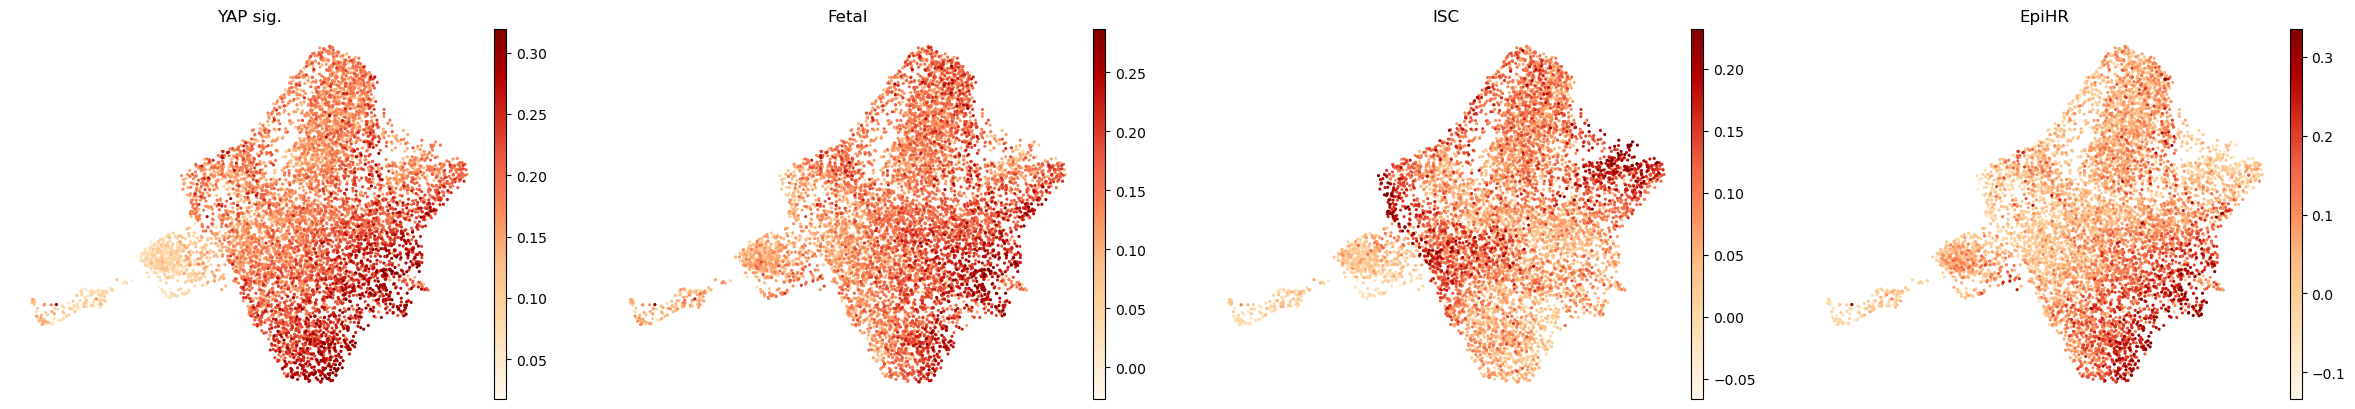

In [ ]:
# Settings for UMAPs of gene set scores
vmax = 'p99.5'
dot_size = 120000 / adata.shape[0] * 1.25

# Plotting labels for gene set scores
feature_labels = {
    'score_YAP': 'YAP sig.',
    'score_fetal': 'Fetal',
    'score_Lgr5': 'ISC',
    'score_epiHR': 'EpiHR',
}

# Make UMAPs of gene set scores
print("UMAPs of gene set scores:") 
sc.pl.umap(
    adata, color=feature_labels.keys(), 
    size=dot_size,
    title=feature_labels.values(),
    cmap='OrRd', 
    vmax=vmax, 
    frameon=False,
)

UMAPs of gene set scores:


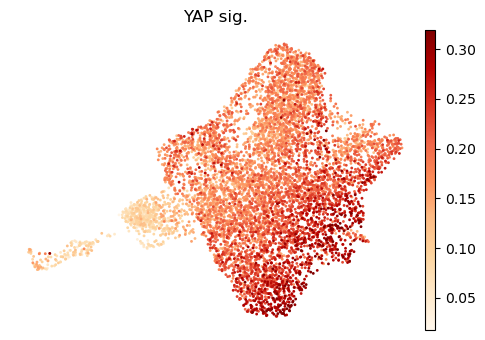

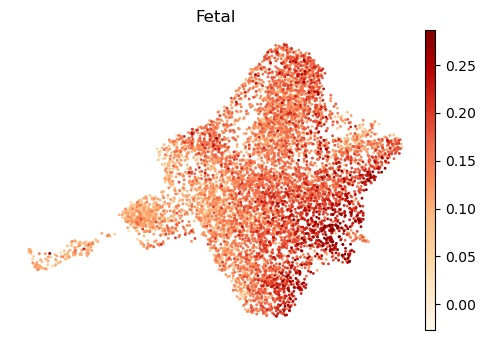

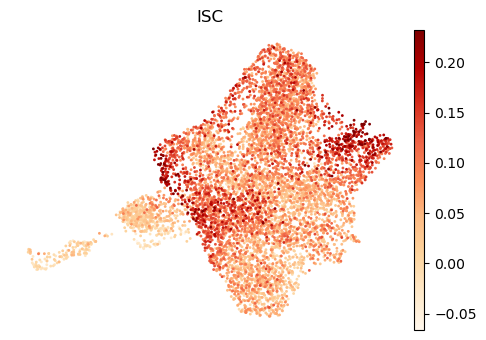

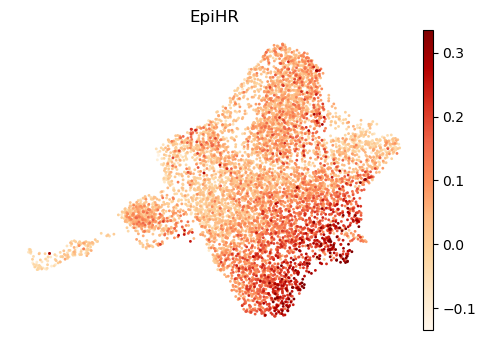

In [ ]:
# Define plotting parameters
vmax = 'p99.5'
dot_size = 120000 / adata.shape[0] * 1.25

# Make UMAPs of gene set scores
print("UMAPs of gene set scores:")
for feature in gs_process:    
    # Plot and save UMAPs
    fig = sc.pl.umap(
        adata, 
        color = feature, 
        layer = 'log1p',
        cmap = 'OrRd',
        vmax=vmax,
        title=feature_labels[feature],
        frameon = False,
        legend_loc='right margin',
        return_fig=True,
        show=False,
    )

    fig.set_size_inches(5,3.5)
    ax = fig.axes[0] 
    plt.tight_layout()
    plt.show()

# Get data from arrayExpress: SG treatment time course liver mets 0h-48h

Data format on arrayExpress needs double-checking for full dataset...

In [3]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata, list_accession_files

accession = "E-MTAB-16849"
download_dir = '../data_arrayExpress'

df_files = list_accession_files(
    accession=accession,
)
print(df_files)

adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    blacklist=[f for f in df_files['path'] if f.startswith('HD4246_SG_mets')],
    dataset = '0h-48h',
)
adata

                                        path        size  type   md5
0                HD4246_SG_0h-48h_counts.txt  1261067986  file  None
1     HD4246_SG_0h-48h_counts_log1p_woCC.txt  3810408828  file  None
2              HD4246_SG_0h-48h_features.txt      221441  file  None
3              HD4246_SG_0h-48h_metadata.txt      783941  file  None
4                  HD4246_SG_0h-48h_umap.txt      478836  file  None
5              HD4246_SG_48h-120h_counts.txt  1549173732  file  None
6   HD4246_SG_48h-120h_counts_log1p_woCC.txt  4717617770  file  None
7            HD4246_SG_48h-120h_features.txt      221441  file  None
8            HD4246_SG_48h-120h_metadata.txt      993348  file  None
9                HD4246_SG_48h-120h_umap.txt      593587  file  None
10                 HD4246_SG_mets_counts.txt  3202358648  file  None
11               HD4246_SG_mets_features.txt      221441  file  None
12               HD4246_SG_mets_metadata.txt     3063293  file  None
13                     feature_ref

AnnData object with n_obs × n_vars = 11385 × 27594
    obs: 'sample_id', 'line', 'treatment', 'timepoint', 'replicate', 'library', 'leiden', 'batch'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

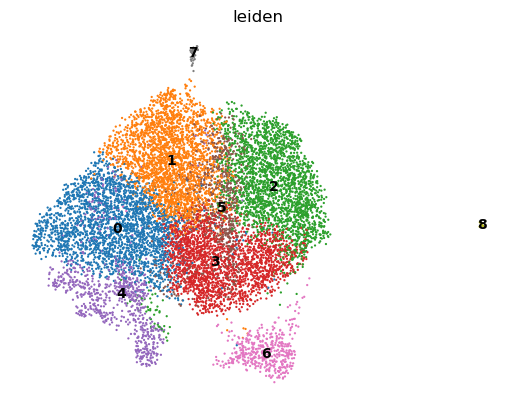

In [9]:
# Ensure order of leiden clustering (str) is available
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
sc.pl.umap(adata, color='leiden', legend_loc='on data', show=True, frameon=False)

In [4]:
# # Read input data
# file = os.path.join(dir_data, "SG_0h_6h_24h_48h_woCC.h5ad")
# adata = sc.read_h5ad(file)

### UMAP split by time point

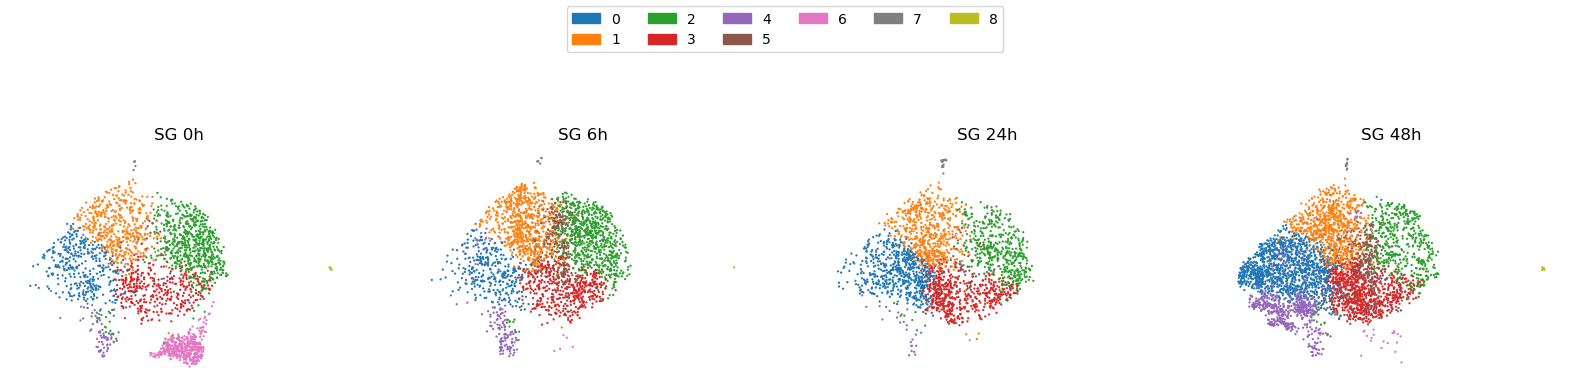

In [10]:
###  UMAP split by timepoint
import matplotlib.patches as mpatches 
import math

splitby = 'timepoint'
colorby = 'leiden'
frameon = False
figsize = (5,5)

# Setup the plot
no_categs = len(adata.obs[splitby].cat.categories)
fig, axes = plt.subplots(1, no_categs, 
                            figsize=(figsize[0] * no_categs, figsize[1]),
                            sharey=True, sharex=True,
                            )
# Ensure axes are iterable also for single category
axes = [axes] if no_categs == 1 else axes

# Make the plots
for idx, (ax, cat) in enumerate(zip(axes, adata.obs[splitby].cat.categories)):
    # Title of subplots
    title = f"SG {cat}"
    dot_size = 120000 / adata.n_obs
    # Subplot
    sc.pl.umap(
        adata[adata.obs[splitby] == cat],
        color=colorby,
        size=dot_size,
        layer=None,
        frameon=frameon,
        ax=ax,
        show=False,
        title=title,
        legend_loc = None,
    )

    # Keep UMAP square
    ax.set_aspect("equal", "box")

# --- rebuild legend from AnnData instead of handles ---
# Legend for categorical feature
if colorby in adata.obs and str(adata.obs[colorby].dtype) == "category":
    categories = list(adata.obs[colorby].cat.categories)
    # Ensure color code exists
    if colorby + "_colors" not in adata.uns:
        sc.pl.umap(adata, color=colorby)
    colors = adata.uns[colorby + "_colors"]
    patches = [mpatches.Patch(color=col, label=lab)
            for lab, col in zip(categories, colors)]
    ncol = min(6, len(categories))
    # Make the legend
    fig.legend(
        handles=patches,
        loc="upper center",
        ncol=ncol,
        frameon=True,
    )
    # Trying to adapt top margin dynamically
    nrows = math.ceil(len(categories) / ncol)
    top_margin = 0.90 - (nrows - 1) * 0.05
    top_margin = max(0.7, top_margin)
    # Set top margin for legend
    plt.subplots_adjust(top=top_margin)

fig.show()


### Cluster size difference over time

In [11]:
# Difference in cluster size between 48h and 0h
def get_composition(adata, x, y, cond=None,  abs_count=True):

    # Use index as cell barcode column
    cell_bc="cell_bc"
    adata.obs[cell_bc] = adata.obs.index

    # Compute absolute frequency table
    freq = adata.obs.pivot_table(index=x, columns=cond, values=[cell_bc], aggfunc={cell_bc: 'count'})
    # Rename columns
    cell_count_label = 'no_cells'
    colnames = {cell_bc: cell_count_label,}
    freq.rename(columns=colnames, inplace=True)
    
    # Adapt column labels and normalize data if applicable
    if not abs_count:
        # Normalize data and write to new object
        freq_rel = freq.div(freq.sum(axis=1), axis=0)*100
        # Rename columns
        cell_count_label = 'rel_no_cells'
        colnames = {'no_cells': cell_count_label,}
        freq_rel.rename(columns=colnames, inplace=True)
    
    if abs_count:
        return freq
    else:
        return freq_rel

# Get relative composition of clusters across samples
df = get_composition(adata, x='sample_id', y='count', cond='leiden', abs_count=False)

# Convert to long format
df = df.stack().reset_index()
df['treatment'] = [x.split('_')[1] for x in df['sample_id']]
df['timepoint'] = [x.split('_')[2] for x in df['sample_id']]
df['sample_name'] = [x.rsplit('_',1)[0] for x in df['sample_id']]
print(df.head(2))

            sample_id leiden  rel_no_cells treatment timepoint   sample_name
0  HD4246_SG_0h_repl1      0     14.929817        SG        0h  HD4246_SG_0h
1  HD4246_SG_0h_repl1      1     19.225861        SG        0h  HD4246_SG_0h


/tmp/ipykernel_2832784/2212485140.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq = adata.obs.pivot_table(index=x, columns=cond, values=[cell_bc], aggfunc={cell_bc: 'count'})
/tmp/ipykernel_2832784/2212485140.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack().reset_index()


/tmp/ipykernel_2832784/4284462774.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sum = df.groupby(['timepoint', 'leiden'])['rel_no_cells'].mean().reset_index()
/tmp/ipykernel_2832784/4284462774.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='leiden', y='diff', data=pivot_df.reset_index(), palette=leiden_colors)


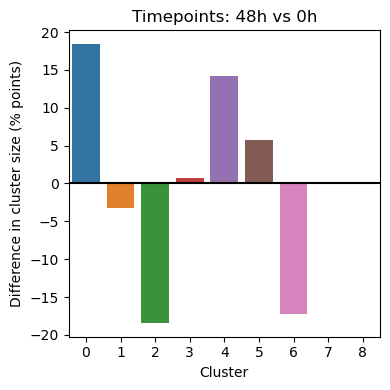

In [22]:
### Plot cluster difference between 48h and 0h

# Extract leiden colors from adata
leiden_colors = adata.uns['leiden_colors']

# Summarize relative composition by treatment and cluster
df_sum = df.groupby(['timepoint', 'leiden'])['rel_no_cells'].mean().reset_index()

# Get df subset with only 48h and 0h timepoints
df_sub = df_sum[df_sum['timepoint'].isin(['48h', '0h'])]

# Get difference between treatment options: '48h' - ADC
pivot_df = df_sub.pivot(index='leiden', columns='timepoint', values='rel_no_cells')
pivot_df['diff'] = pivot_df['48h'] - pivot_df['0h']
pivot_df.to_csv(f'../data_suppl/{accession}_Ext_Fig_07c.csv')

### Graphical output
# Plot diff as bargraph
plt.figure(figsize=(4,4))
sns.barplot(x='leiden', y='diff', data=pivot_df.reset_index())
plt.xlabel('Cluster')
plt.ylabel('Difference in cluster size (% points)')
# Add horizonal line at y=0
plt.axhline(0, color='black')
sns.barplot(x='leiden', y='diff', data=pivot_df.reset_index(), palette=leiden_colors)
plt.title(f'Timepoints: 48h vs 0h')
plt.tight_layout()
plt.show()

In [5]:
# Fisher’s exact test for label enrichment
from scipy.stats import fisher_exact

def run_fisher_test(adata, categ_key, test_key, test_label):
    df = adata.obs[[categ_key, test_key]].copy()
    df['is_target'] = (df[test_key] == test_label).astype(int)
    
    results = []
    for cluster in df[categ_key].unique():
        in_cluster = df[categ_key] == cluster
        out_cluster = ~in_cluster

        # Build contingency table:
        #                in_cluster   out_cluster
        # target_label        a            b
        # not_target          c            d
        a = df[in_cluster]['is_target'].sum()
        b = df[out_cluster]['is_target'].sum()
        c = in_cluster.sum() - a
        d = out_cluster.sum() - b
        
        table = [[a, b], [c, d]]
        odds_ratio, p = fisher_exact(table, alternative='greater')  # test enrichment

        results.append({
            'category': categ_key,
            'categ_label': cluster,
            'test_group': test_key,
            'test_label': test_label,
            'odds_ratio': odds_ratio,
            'p_value': p,
            'n_target_in_categ_label': a,
            'n_total_in_categ_label': in_cluster.sum()
        })

    # Return data frame
    return pd.DataFrame(results).sort_values('p_value')

In [6]:
def sort_df_for_plotting(df, sort_configs):
    df = df.copy()

    sort_by = []
    temp_sort_keys = []

    # Step 1: Prepare sorting keys (either categorical order or numeric sort key)
    for config in sort_configs:
        col = config['column']
        order = config.get('order')
        sort_as_numeric = config.get('sort_as_numeric', False)

        if order is not None:
            # Use explicit order
            df[col] = pd.Categorical(df[col], categories=order, ordered=True)
            sort_by.append(col)

        elif sort_as_numeric:
            # Use temp numeric column for sorting
            temp_col = f'_sort_{col}'
            df[temp_col] = pd.to_numeric(df[col], errors='coerce')
            sort_by.append(temp_col)
            temp_sort_keys.append(temp_col)

    # Step 2: Sort using combined keys
    df = df.sort_values(by=sort_by).reset_index(drop=True)

    # Step 3: Assign ordered Categorical to original string column, based on numeric sort
    for config in sort_configs:
        col = config['column']
        if config.get('sort_as_numeric', False):
            sorted_unique_vals = df[col].dropna().unique()
            df[col] = pd.Categorical(df[col], categories=sorted_unique_vals, ordered=True)

    # Step 4: Re-sort based on original (now-ordered) columns
    df = df.sort_values(by=[cfg['column'] for cfg in sort_configs]).reset_index(drop=True)

    # Step 5: Drop temporary sort columns
    df = df.drop(columns=temp_sort_keys, errors='ignore')

    return df

In [7]:
# Plot results of Fisher test
def dotplot_fisher_test(
    res_df,
    file_ext='',
    pval_thres=None,
    figsize=(5, 5),
    size_cap=None,
    oddsratio_cap=None,          # <-- NEW: cap for odds ratio (upper limit / saturation)
    categ_key='category',
    categ_label='categ_label',
    test_key='test_group',
    test_label='test_label',
    pval_key='p_value',
    oddsratio_key='odds_ratio',  # <-- NEW: allow changing odds ratio column name
):
    """
    Creates one of two plots:
      1) Full odds ratio color scale (uncapped)
      2) Capped odds ratio color scale (if oddsratio_cap is not None)

    The capped plot gets details appended to file_ext for saving.
    """

    # -----------------------------
    # Helper to make one plot
    # -----------------------------
    def _make_plot(df_plot, hue_col, hue_norm, title_suffix):
        # Convert p-values to -log10 scale for visibility
        df_plot = df_plot.copy()
        df_plot['-log10_p'] = -np.log10(df_plot[pval_key] + 1e-300)

        # Optional: cap log p-value for better scale (bubble size)
        if size_cap is not None:
            size_col = f'-log10_p_capped_{size_cap}'
            df_plot[size_col] = df_plot['-log10_p'].clip(upper=size_cap)
            size_max_for_legend = size_cap
        else:
            size_col = '-log10_p'
            size_max_for_legend = float(np.nanmax(df_plot[size_col].values))

        # Get continuous scale also for small dfs (bubble size)
        # Guard against all-NaN
        size_min = float(np.nanmin(df_plot[size_col].values)) if np.isfinite(np.nanmin(df_plot[size_col].values)) else 0.0
        size_max = float(np.nanmax(df_plot[size_col].values)) if np.isfinite(np.nanmax(df_plot[size_col].values)) else 1.0
        size_norm = plt.Normalize(size_min, size_max) if size_max > size_min else None

        plt.figure(figsize=figsize)
        ax = sns.scatterplot(
            data=df_plot,
            x=test_label,
            y=categ_label,
            size=size_col,
            hue=hue_col,
            hue_norm=hue_norm,
            palette='viridis',
            sizes=(50, 300),
            size_norm=size_norm,
            edgecolor='black',
            legend=False,
        )

        # Colorbar
        sm = plt.cm.ScalarMappable(cmap='viridis', norm=hue_norm)
        sm.set_array([])
        plt.colorbar(
            sm,
            ax=ax,
            label='Odds ratio' + title_suffix,
            fraction=0.05,
            pad=0.04,
            aspect=20,
            shrink=0.5,
            orientation='vertical',
            anchor=(0.5, 0.25),
        )

        # Bubble size legend ticks
        # Use the *displayed* size range for legend labels
        min_size = float(np.nanmin(df_plot[size_col].values)) if np.isfinite(np.nanmin(df_plot[size_col].values)) else 0.0
        max_size = float(np.nanmax(df_plot[size_col].values)) if np.isfinite(np.nanmax(df_plot[size_col].values)) else 1.0
        n_ticks = 4 if max_size - min_size > 2 else 3
        size_vals = np.linspace(min_size, max_size, n_ticks)
        size_vals = np.round(size_vals, 1)

        # Map legend bubble sizes to sizes=(50, 300)
        # If size_cap is set, scale relative to that cap; else relative to max displayed
        denom = size_max_for_legend if (size_cap is not None) else (max_size if max_size > 0 else 1.0)
        for val in size_vals:
            s = 50 + 250 * (val / denom)  # matches sizes=(50, 300)
            plt.scatter([], [], s=s, c='gray', label=f'{val:.1f}')

        plt.legend(
            scatterpoints=1,
            frameon=True,
            labelspacing=1,
            title=size_col,
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
        )

        # Extract meaningful group names (robust to NA rows from reindex)
        non_na_categ = df_plot[categ_key].dropna()
        non_na_test = df_plot[test_key].dropna()
        categ_group = non_na_categ.iloc[0] if len(non_na_categ) else categ_key
        test_group = non_na_test.iloc[0] if len(non_na_test) else test_key

        plt.xlabel(test_group)
        plt.ylabel(categ_group)
        plt.tight_layout()
        # plt.show()

    # -----------------------------
    # 1) Filter by p-value threshold (unchanged logic, but keep it safe for non-unique indices)
    # -----------------------------
    if pval_thres is not None:
        res_df = res_df[res_df[pval_key] < pval_thres].copy()
        file_ext += f'_pval-{pval_thres}'

        if res_df.empty:
            print("No significant hits to display (p > cutoff).")
            return

        # Fill missing combinations with NA
        row_levels = res_df[categ_label].cat.categories if pd.api.types.is_categorical_dtype(res_df[categ_label]) else res_df[categ_label].unique()
        col_levels = res_df[test_label].cat.categories if pd.api.types.is_categorical_dtype(res_df[test_label]) else res_df[test_label].unique()
        full_index = pd.MultiIndex.from_product([row_levels, col_levels], names=[categ_label, test_label])

        # Set index and ensure uniqueness before reindex (prevents "non-unique multi-index" error)
        tmp = res_df.set_index([categ_label, test_label])
        if not tmp.index.is_unique:
            # pick ONE policy; "first" is usually safest for fisher outputs; change if you prefer mean/max
            tmp = tmp.groupby(level=[0, 1]).first()

        res_df = tmp.reindex(full_index).reset_index()

        # Sort results df for plotting
        res_df = sort_df_for_plotting(res_df, sort_configs=sort_configs)

    if oddsratio_cap is None:
        # -----------------------------
        # 2) Make FULL (uncapped) odds ratio plot
        # -----------------------------
        # Norm based on observed odds ratios (ignore NaNs)
        or_min = float(np.nanmin(res_df[oddsratio_key].values))
        or_max = float(np.nanmax(res_df[oddsratio_key].values))
        hue_norm_full = plt.Normalize(or_min, or_max) if or_max > or_min else plt.Normalize(or_min, or_min + 1e-9)

        _make_plot(
            df_plot=res_df,
            hue_col=oddsratio_key,
            hue_norm=hue_norm_full,
            title_suffix='',
        )

    else:
        # -----------------------------
        # 3) Make CAPPED odds ratio plot (optional)
        # -----------------------------
        capped_col = f'{oddsratio_key}_capped_{oddsratio_cap}'
        res_df_capped = res_df.copy()
        res_df_capped[capped_col] = res_df_capped[oddsratio_key].clip(upper=oddsratio_cap)

        # Important: saturation effect by fixing upper bound at oddsratio_cap
        or_min_c = float(np.nanmin(res_df_capped[capped_col].values))
        hue_norm_capped = plt.Normalize(or_min_c, oddsratio_cap) if oddsratio_cap > or_min_c else plt.Normalize(or_min_c, or_min_c + 1e-9)

        file_ext_capped = file_ext + f'_ORcap-{oddsratio_cap}'

        _make_plot(
            df_plot=res_df_capped,
            hue_col=capped_col,
            hue_norm=hue_norm_capped,
            title_suffix=f' (capped at {oddsratio_cap})',
        )

In [20]:
leiden_key = 'leiden'

categ_key = leiden_key
categ_label_order = None
categ_sort_numeric = True

test_groups = {
    'timepoint': {
        'label_order': ['0h', '6h', '24h', '48h', '72h', '120h'],
        'sort_numeric': False,
    },
}

oddsratio_cap = 6

# Iterate over each test group
for test_key, test_params in test_groups.items():
    test_label_order = test_params['label_order']
    test_sort_numeric = test_params['sort_numeric']
    print(f"Processing test_key: {test_key} with label order {test_label_order} and sort_numeric={test_sort_numeric}")

    # Sort configs for easy sorting of Fisher’s results df
    sort_configs = [
        {
            'column': 'test_label',
            'order': test_label_order,
            'sort_as_numeric': test_sort_numeric
        },
        # Do category sorting last to ensure this one has priority
        {
            'column': 'categ_label',
            'order': categ_label_order,
            'sort_as_numeric': categ_sort_numeric
        },
    ]

    # Pre-flight checks
    groups = [categ_key, test_key]
    if not all([cond in adata.obs.columns for cond in groups]):
        raise NameError(f"Not all variables {groups} are part of dataset.")
    
    ### Run Fisher’s exact test
    print("Running Fisher’s exact test...")
    # Test enrichment of each treatment label across leiden categories
    results_df = []
    for label in adata.obs[test_key].unique():
        res = run_fisher_test(adata, categ_key=categ_key, test_key=test_key, test_label=label)
        results_df.append(res)
    results_df = pd.concat(results_df, ignore_index=True)

    # Sort resulting df
    results_df = sort_df_for_plotting(results_df, sort_configs = sort_configs)

# Write results to disk and display
results_df.to_csv(f'../data_suppl/{accession}_Ext_Fig_07d.csv', index=False)
results_df

Processing test_key: timepoint with label order ['0h', '6h', '24h', '48h', '72h', '120h'] and sort_numeric=False
Running Fisher’s exact test...


,category,categ_label,test_group,test_label,odds_ratio,p_value,n_target_in_categ_label,n_total_in_categ_label
0,leiden,0,timepoint,0h,0.564681,1.000000e+00,351,2493
1,leiden,1,timepoint,0h,0.830173,9.994528e-01,452,2465
2,leiden,2,timepoint,0h,1.724299,1.135169e-23,656,2312
3,leiden,3,timepoint,0h,0.721656,1.000000e+00,360,2170
4,leiden,4,timepoint,0h,0.373818,1.000000e+00,72,776
5,leiden,5,timepoint,0h,0.168674,1.000000e+00,30,673
6,leiden,6,timepoint,0h,69.958571,2.354616e-260,420,448
7,leiden,7,timepoint,0h,0.511518,9.413591e-01,4,34
8,leiden,8,timepoint,0h,2.886780,5.034393e-02,6,14
9,leiden,0,timepoint,6h,0.415943,1.000000e+00,320,2493


/tmp/ipykernel_2832784/414484764.py:124: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  row_levels = res_df[categ_label].cat.categories if pd.api.types.is_categorical_dtype(res_df[categ_label]) else res_df[categ_label].unique()
/tmp/ipykernel_2832784/414484764.py:125: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  col_levels = res_df[test_label].cat.categories if pd.api.types.is_categorical_dtype(res_df[test_label]) else res_df[test_label].unique()


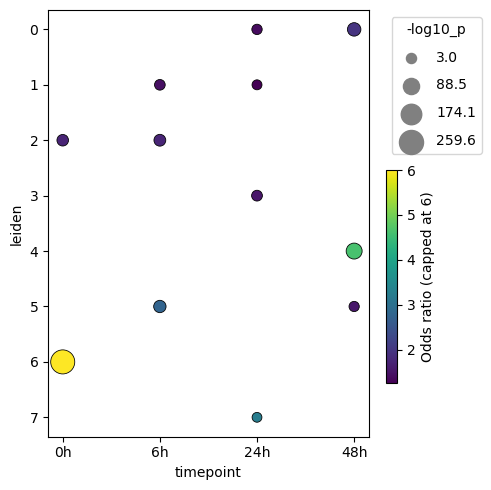

In [21]:
# Plot and save dotplot: all results and significant results only
dotplot_fisher_test(results_df, size_cap = None, pval_thres=0.05, oddsratio_cap=oddsratio_cap)

### Reading palantir data object

In [3]:
import palantir

In [19]:
dir_data = '../data/palantir/'
files = os.listdir(dir_data)
files = [f for f in files if f.endswith('.h5ad')]
files

['Org_chemo_LM3_woCC_palantir_v00.h5ad',
 'HD4246_SG_0h-48h_palantir.h5ad',
 'HD4246_SG_48-120h_palantir.h5ad',
 'SG_0h_6h_24h_48h_woCC_res0.4_cl0-6_v01_palantir.h5ad',
 'Org_chemo_LM3_palantir.h5ad',
 'SG_48h_72h_120h_woCC_v02b_palantir.h5ad']

In [20]:
file = '../data/palantir/HD4246_SG_0h-48h_palantir.h5ad'
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 11337 × 27594
    obs: 'sample_id', 'line', 'treatment', 'timepoint', 'replicate', 'library', 'leiden', 'batch', 'palantir_pseudotime', 'palantir_entropy'
    var: 'dispersions', 'dispersions_norm', 'gene_trends_clusters'
    uns: 'DM_EigenValues', 'leiden_colors', 'neighbors', 'palantir_start_state', 'palantir_terminal_states', 'palantir_waypoints', 'sample_id_colors', 'timepoint_colors', 'treatment_colors'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_pca', 'X_umap', 'branch_masks', 'palantir_fate_probabilities'
    varm: 'PCs', 'gene_trends_Term_DM1_max', 'gene_trends_Term_DM2_min'
    layers: 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [21]:
# Pick branch color from color code
from utils_SG_timecourse import color_code
branches = ['Term_DM2_min', 'Term_DM1_max']
branch_color = {
    'Term_DM2_min': '#672892',
    'Term_DM1_max': '#854f9c',
}
# Mapping of interpretable branch names
branch_title = {
    "Term_DM2_min": "Main trajectory",
    "Term_DM1_max": "Side trajectory",
}

### Plotting palantir results

[2026-04-27 22:42:10,164] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (3,118) and rank = 1.0.
[2026-04-27 22:42:10,165] [INFO    ] Using covariance function Matern52(ls=0.8957839012145996).
[2026-04-27 22:42:10,179] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-04-27 22:42:10,962] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-04-27 22:42:11,063] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (3,148) and rank = 1.0.
[2026-04-27 22:42:11,064] [INFO    ] Using covariance function Matern52(ls=0.8957839012145996).
[2026-04-27 22:42:11,077] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-04-27 22:42:12,454] [INFO    ] Sigma interpreted as element-wise standard deviation.


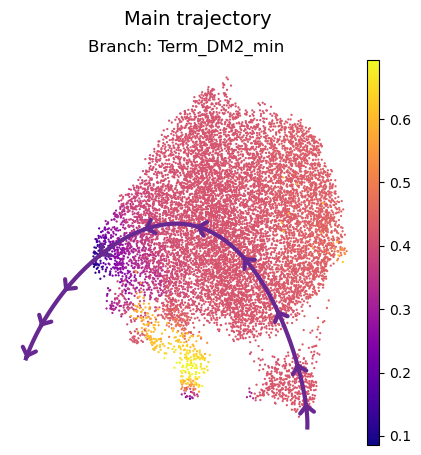

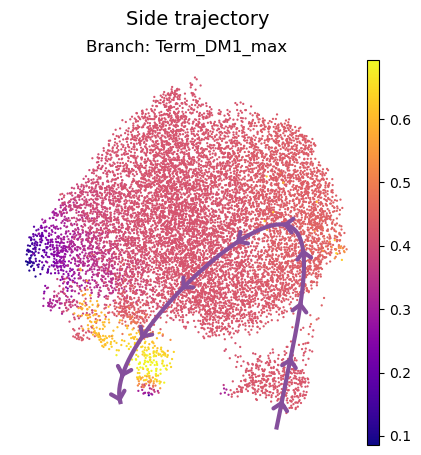

In [22]:
# Plot branches on UMAP colored by entropy
entropy_cmap = 'plasma'

for branch in branches:
    color = 'palantir_entropy'
    palantir.plot.plot_trajectory(
        adata, # your anndata
        branch, # the branch to plot
        cell_color="palantir_entropy", # the ad.obs colum to color the cells by
        n_arrows=10, # the number of arrow heads along the path
        color=branch_color[branch], # the color of the path and arrow heads
        scanpy_kwargs=dict(cmap=entropy_cmap), # arguments passed to scanpy.pl.embedding
        arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3), # appearance of the arrow heads
        lw=3, # thickness of the path
        pseudotime_interval=(0, .9), # interval of the pseudotime to cover with the path
    )
    fig = plt.gcf()
    fig.suptitle(branch_title[branch], fontsize=14)
    fig.show()

In [23]:
# Compute gene trends
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

Term_DM1_max


[2026-04-27 22:42:15,099] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (3,148) and rank = 1.0.
[2026-04-27 22:42:15,100] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-04-27 22:42:15,673] [INFO    ] Sigma interpreted as element-wise standard deviation.
Term_DM2_min
[2026-04-27 22:42:20,310] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (3,118) and rank = 1.0.
[2026-04-27 22:42:20,311] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-04-27 22:42:20,865] [INFO    ] Sigma interpreted as element-wise standard deviation.


In [24]:
# Extract gene expression along pseudotime
genes = ["TACSTD2", "LGR5"]

df_expr = pd.concat(
    {
        (gene, br): (
            adata.varm[f"gene_trends_{br}"]
            .loc[gene]
            .astype(float)
            .reset_index(drop=True)
        )
        for gene in genes
        for br in branches
    },
    axis=1
)

df_expr.index.name = "pseudotime_bin"

df_expr.head(2)

TACSTD2                      LGR5             
               Term_DM2_min Term_DM1_max Term_DM2_min Term_DM1_max
pseudotime_bin                                                    
0                  2.656494     2.664230     0.097860     0.071987
1                  2.654413     2.660632     0.098086     0.072855

In [25]:
import matplotlib.pyplot as plt

def plot_gene_expression_from_df(df_expr, 
                                 branch_name,
                                 color_trop2='green', 
                                 color_lgr5='red',
                                 linewidth=4,
                                 scale_min_max = False,
                                 title = None,
                                 figsize=(8, 6)):
    # Extract expression data for both genes from the df_expr dictionary
    tacstd2_expr = df_expr[('TACSTD2', branch_name)]  # Directly use the ndarray
    lgr5_expr = df_expr[('LGR5', branch_name)]  # Directly use the ndarray

    # Scale expression per gene if indicated
    if scale_min_max:
        tac_min, tac_max = np.nanmin(tacstd2_expr), np.nanmax(tacstd2_expr)
        lgr5_min, lgr5_max = np.nanmin(lgr5_expr), np.nanmax(lgr5_expr)

        # avoid division by zero if a gene is constant
        if tac_max > tac_min:
            tacstd2_expr = (tacstd2_expr - tac_min) / (tac_max - tac_min)
        else:
            tacstd2_expr = np.zeros_like(tacstd2_expr, dtype=float)

        if lgr5_max > lgr5_min:
            lgr5_expr = (lgr5_expr - lgr5_min) / (lgr5_max - lgr5_min)
        else:
            lgr5_expr = np.zeros_like(lgr5_expr, dtype=float)
        

    # Create an array for pseudotime (assuming row indices represent pseudotime points)
    pseudotime = range(len(tacstd2_expr))

    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

    # Plot the expression for TACSTD2 and LGR5
    ax.plot(pseudotime, tacstd2_expr, label='TACSTD2', color=color_trop2, linewidth=linewidth)
    ax.plot(pseudotime, lgr5_expr, label='LGR5', color=color_lgr5, linewidth=linewidth)

    # Add labels and title
    title = "" if title is None else title
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Pseudotime", fontsize=14)
    ax.set_ylabel("Scaled expression", fontsize=14)

    # Add a legend
    ax.legend(title="", frameon=False)

    # Show the plot
    plt.tight_layout()
    plt.show()

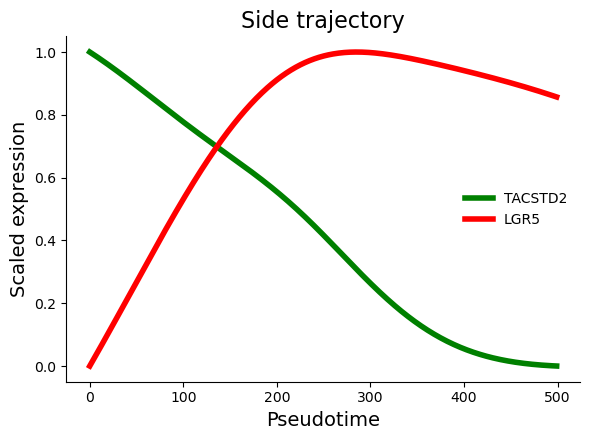

In [26]:
# Get scaled gene expression along pseudotime for main trajectory (Term_DM2_min)
plot_gene_expression_from_df(
    df_expr, 
    branch_name='Term_DM1_max', 
    scale_min_max=True,
    title = "Side trajectory",
    figsize=(6, 4.5),
)

# Get data from arrayExpress: SG treatment time course liver mets 48h-120h

Data format on arrayExpress needs double-checking for full dataset...

In [3]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata, list_accession_files

accession = "E-MTAB-16849"
download_dir = '../data_arrayExpress'

df_files = list_accession_files(
    accession=accession,
)
print(df_files)

adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    blacklist=[f for f in df_files['path'] if f.startswith('HD4246_SG_mets')],
    dataset = '48h-120h',
)
adata

                                        path        size  type   md5
0                HD4246_SG_0h-48h_counts.txt  1261067986  file  None
1     HD4246_SG_0h-48h_counts_log1p_woCC.txt  3810408828  file  None
2              HD4246_SG_0h-48h_features.txt      221441  file  None
3              HD4246_SG_0h-48h_metadata.txt      783941  file  None
4                  HD4246_SG_0h-48h_umap.txt      478836  file  None
5              HD4246_SG_48h-120h_counts.txt  1549173732  file  None
6   HD4246_SG_48h-120h_counts_log1p_woCC.txt  4717617770  file  None
7            HD4246_SG_48h-120h_features.txt      221441  file  None
8            HD4246_SG_48h-120h_metadata.txt      993348  file  None
9                HD4246_SG_48h-120h_umap.txt      593587  file  None
10                 HD4246_SG_mets_counts.txt  3202358648  file  None
11               HD4246_SG_mets_features.txt      221441  file  None
12               HD4246_SG_mets_metadata.txt     3063293  file  None
13                     feature_ref

AnnData object with n_obs × n_vars = 13984 × 27594
    obs: 'sample_id', 'line', 'treatment', 'timepoint', 'replicate', 'library', 'leiden', 'batch'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

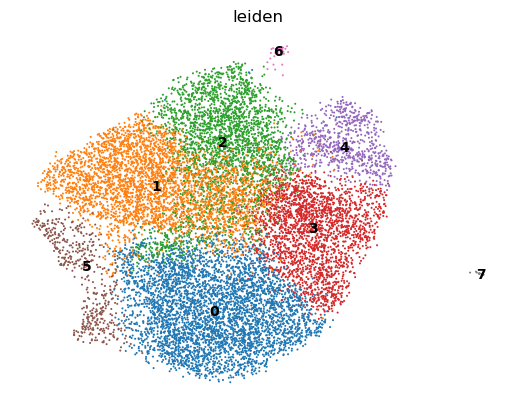

In [4]:
# Ensure order of leiden clustering (str) is available
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
sc.pl.umap(adata, color='leiden', legend_loc='on data', show=True, frameon=False)

In [5]:
# # Read input data
# file = os.path.join(dir_data, "SG_48h_72h_120h_woCC.h5ad")
# adata = sc.read_h5ad(file)

In [6]:
# Import magic imputation results
import utils
utils.import_magic(adata, final_id='HD4246_SG_mets_merged', path_magic='../data/magic')

Importing MAGIC results...


### UMAP split by timepoint

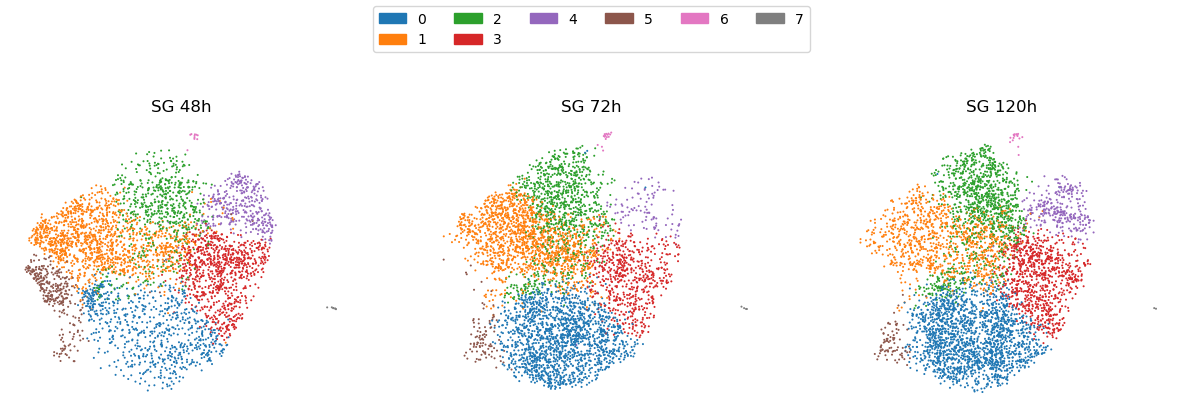

In [25]:
###  UMAP split by timepoint
import matplotlib.patches as mpatches 
import math

splitby = 'timepoint'
colorby = 'leiden'
frameon = False
figsize = (5,5)

# Setup the plot
no_categs = len(adata.obs[splitby].cat.categories)
fig, axes = plt.subplots(1, no_categs, 
                            figsize=(figsize[0] * no_categs, figsize[1]),
                            sharey=True, sharex=True,
                            )
# Ensure axes are iterable also for single category
axes = [axes] if no_categs == 1 else axes

# Make the plots
for idx, (ax, cat) in enumerate(zip(axes, adata.obs[splitby].cat.categories)):
    # Title of subplots
    title = f"SG {cat}"
    dot_size = 120000 / adata.n_obs
    # Subplot
    sc.pl.umap(
        adata[adata.obs[splitby] == cat],
        color=colorby,
        size=dot_size,
        layer=None,
        frameon=frameon,
        ax=ax,
        show=False,
        title=title,
        legend_loc = None,
    )

    # Keep UMAP square
    ax.set_aspect("equal", "box")

# --- rebuild legend from AnnData instead of handles ---
# Legend for categorical feature
if colorby in adata.obs and str(adata.obs[colorby].dtype) == "category":
    categories = list(adata.obs[colorby].cat.categories)
    # Ensure color code exists
    if colorby + "_colors" not in adata.uns:
        sc.pl.umap(adata, color=colorby)
    colors = adata.uns[colorby + "_colors"]
    patches = [mpatches.Patch(color=col, label=lab)
            for lab, col in zip(categories, colors)]
    ncol = min(6, len(categories))
    # Make the legend
    fig.legend(
        handles=patches,
        loc="upper center",
        ncol=ncol,
        frameon=True,
    )
    # Trying to adapt top margin dynamically
    nrows = math.ceil(len(categories) / ncol)
    top_margin = 0.90 - (nrows - 1) * 0.05
    top_margin = max(0.7, top_margin)
    # Set top margin for legend
    plt.subplots_adjust(top=top_margin)

fig.show()


In [ ]:
# ###  UMAP split by timepoint

# # Observation masks
# masks = {tp: adata.obs['timepoint'] == tp for tp in adata.obs['timepoint'].unique()}

# # Plot UMAPs
# dot_size = 120000 / adata.n_obs
# for tp in adata.obs['timepoint'].cat.categories:
#     sc.pl.umap(
#         adata.copy(), 
#         color=['leiden'], 
#         size=dot_size,
#         frameon=False, 
#         title=f"SG {tp}", 
#         mask_obs=masks[tp], 
#         na_color='white'
#     )


### Cluster size difference over time

In [8]:
# Difference in cluster size between 120h and 48h
def get_composition(adata, x, y, cond=None,  abs_count=True):

    # Use index as cell barcode column
    cell_bc="cell_bc"
    adata.obs[cell_bc] = adata.obs.index

    # Compute absolute frequency table
    freq = adata.obs.pivot_table(index=x, columns=cond, values=[cell_bc], aggfunc={cell_bc: 'count'})
    # Rename columns
    cell_count_label = 'no_cells'
    colnames = {cell_bc: cell_count_label,}
    freq.rename(columns=colnames, inplace=True)
    
    # Adapt column labels and normalize data if applicable
    if not abs_count:
        # Normalize data and write to new object
        freq_rel = freq.div(freq.sum(axis=1), axis=0)*100
        # Rename columns
        cell_count_label = 'rel_no_cells'
        colnames = {'no_cells': cell_count_label,}
        freq_rel.rename(columns=colnames, inplace=True)
    
    if abs_count:
        return freq
    else:
        return freq_rel

# Get relative composition of clusters across samples
df = get_composition(adata, x='sample_id', y='count', cond='leiden', abs_count=False)

# Convert to long format
df = df.stack().reset_index()
df['treatment'] = [x.split('_')[1] for x in df['sample_id']]
df['timepoint'] = [x.split('_')[2] for x in df['sample_id']]
df['sample_name'] = [x.rsplit('_',1)[0] for x in df['sample_id']]
print(df.head(2))

             sample_id leiden  rel_no_cells treatment timepoint    sample_name
0  HD4246_SG_48h_repl1      0     13.115846        SG       48h  HD4246_SG_48h
1  HD4246_SG_48h_repl1      1     52.197071        SG       48h  HD4246_SG_48h


/tmp/ipykernel_3058665/633273165.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq = adata.obs.pivot_table(index=x, columns=cond, values=[cell_bc], aggfunc={cell_bc: 'count'})
/tmp/ipykernel_3058665/633273165.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.stack().reset_index()


/tmp/ipykernel_3058665/2480675590.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sum = df.groupby(['timepoint', 'leiden'])['rel_no_cells'].mean().reset_index()
/tmp/ipykernel_3058665/2480675590.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='leiden', y='diff', data=pivot_df.reset_index(), palette=leiden_colors)


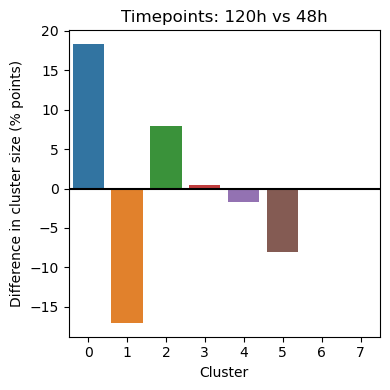

In [9]:
### Plot cluster difference between 120h and 48h

# Extract leiden colors from adata
leiden_colors = adata.uns['leiden_colors']

# Summarize relative composition by treatment and cluster
df_sum = df.groupby(['timepoint', 'leiden'])['rel_no_cells'].mean().reset_index()

# Get df subset with only 120h and 48h timepoints
df_sub = df_sum[df_sum['timepoint'].isin(['120h', '48h'])]

# Get difference between treatment options: '48h' - ADC
pivot_df = df_sub.pivot(index='leiden', columns='timepoint', values='rel_no_cells')
pivot_df['diff'] = pivot_df['120h'] - pivot_df['48h']
pivot_df['log2FC'] = np.log2(pivot_df['120h'] / pivot_df['48h'])
pivot_df.to_csv(f'../data_suppl/{accession}_Ext_Fig_07h.csv')

### Graphical output
# Plot diff as bargraph
plt.figure(figsize=(4,4))
sns.barplot(x='leiden', y='diff', data=pivot_df.reset_index())
plt.xlabel('Cluster')
plt.ylabel('Difference in cluster size (% points)')
# Add horizonal line at y=0
plt.axhline(0, color='black')
sns.barplot(x='leiden', y='diff', data=pivot_df.reset_index(), palette=leiden_colors)
plt.title(f'Timepoints: 120h vs 48h')
plt.tight_layout()
plt.show()

In [10]:
leiden_key = 'leiden'

categ_key = leiden_key
categ_label_order = None
categ_sort_numeric = True

test_groups = {
    'timepoint': {
        'label_order': ['0h', '6h', '24h', '48h', '72h', '120h'],
        'sort_numeric': False,
    },
}

oddsratio_cap = 6

# Iterate over each test group
for test_key, test_params in test_groups.items():
    test_label_order = test_params['label_order']
    test_sort_numeric = test_params['sort_numeric']
    print(f"Processing test_key: {test_key} with label order {test_label_order} and sort_numeric={test_sort_numeric}")

    # Sort configs for easy sorting of Fisher’s results df
    sort_configs = [
        {
            'column': 'test_label',
            'order': test_label_order,
            'sort_as_numeric': test_sort_numeric
        },
        # Do category sorting last to ensure this one has priority
        {
            'column': 'categ_label',
            'order': categ_label_order,
            'sort_as_numeric': categ_sort_numeric
        },
    ]

    # Pre-flight checks
    groups = [categ_key, test_key]
    if not all([cond in adata.obs.columns for cond in groups]):
        raise NameError(f"Not all variables {groups} are part of dataset.")
    
    ### Run Fisher’s exact test
    print("Running Fisher’s exact test...")
    # Test enrichment of each treatment label across leiden categories
    results_df = []
    for label in adata.obs[test_key].unique():
        res = run_fisher_test(adata, categ_key=categ_key, test_key=test_key, test_label=label)
        results_df.append(res)
    results_df = pd.concat(results_df, ignore_index=True)

    # Sort resulting df
    results_df = sort_df_for_plotting(results_df, sort_configs = sort_configs)

# Write results to disk and display
results_df.to_csv(f'../data_suppl/{accession}_Ext_Fig_07i.csv', index=False)
results_df

Processing test_key: timepoint with label order ['0h', '6h', '24h', '48h', '72h', '120h'] and sort_numeric=False
Running Fisher’s exact test...


,category,categ_label,test_group,test_label,odds_ratio,p_value,n_target_in_categ_label,n_total_in_categ_label
0,leiden,0,timepoint,48h,0.412759,1.000000e+00,739,4124
1,leiden,1,timepoint,48h,1.418618,1.041305e-17,1311,3726
2,leiden,2,timepoint,48h,0.676868,1.000000e+00,619,2642
3,leiden,3,timepoint,48h,1.443943,4.532787e-14,811,2227
4,leiden,4,timepoint,48h,2.237399,3.712054e-25,345,728
5,leiden,5,timepoint,48h,4.450627,2.428737e-56,308,482
6,leiden,6,timepoint,48h,0.763830,8.184100e-01,10,41
7,leiden,7,timepoint,48h,2.371953,8.858819e-02,7,14
8,leiden,0,timepoint,72h,1.330632,8.821311e-14,1602,4124
9,leiden,1,timepoint,72h,1.337452,1.659406e-13,1458,3726


/tmp/ipykernel_3058665/414484764.py:124: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  row_levels = res_df[categ_label].cat.categories if pd.api.types.is_categorical_dtype(res_df[categ_label]) else res_df[categ_label].unique()
/tmp/ipykernel_3058665/414484764.py:125: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  col_levels = res_df[test_label].cat.categories if pd.api.types.is_categorical_dtype(res_df[test_label]) else res_df[test_label].unique()


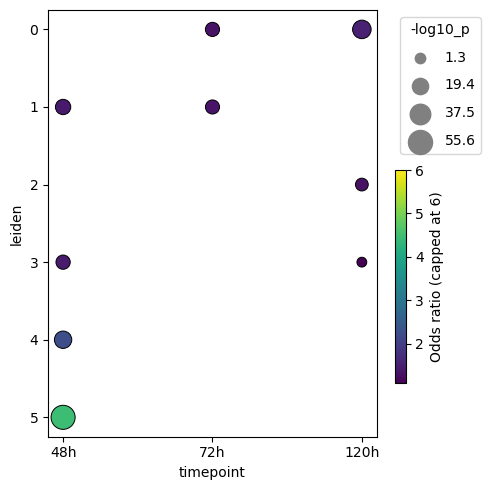

In [11]:
# Plot and save dotplot: all results and significant results only
dotplot_fisher_test(results_df, size_cap = None, pval_thres=0.05, oddsratio_cap=oddsratio_cap)

### Metadata on UMAP

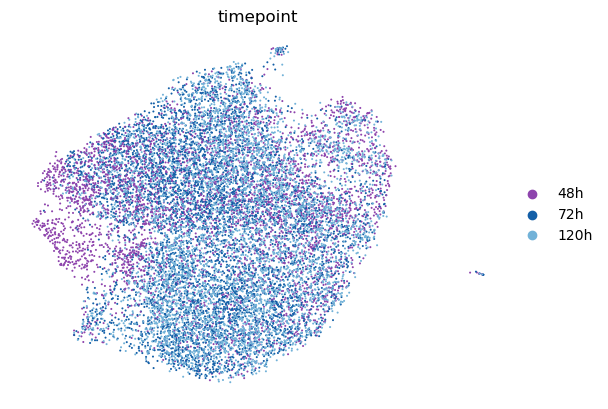

In [12]:
from utils_SG_timecourse import color_code
import utils
utils.set_uns_colors(adata, color_code, key='timepoint')
sc.pl.umap(adata, color='timepoint', frameon=False)

### Gene expression TACSTD2 and LGR5

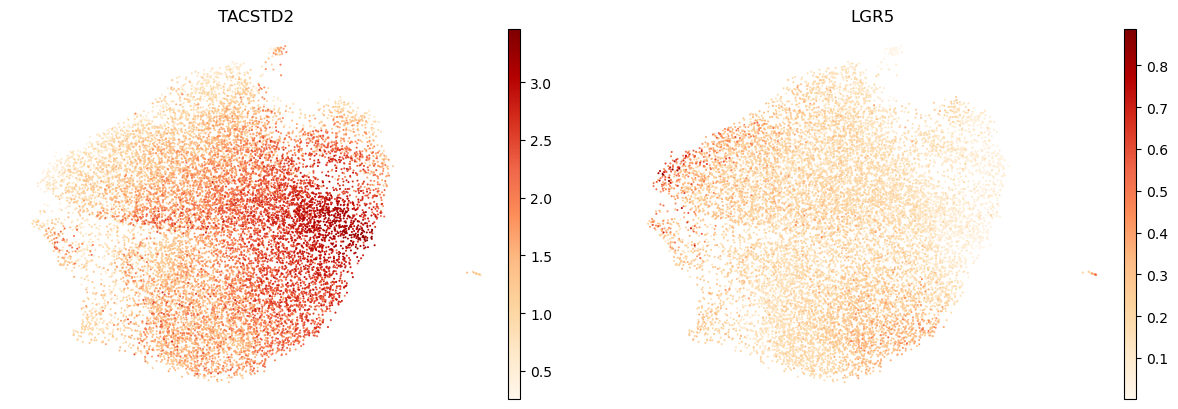

In [7]:
sc.pl.umap(
    adata, 
    color=['TACSTD2', 'LGR5'], 
    layer='magic',
    cmap='OrRd',
    frameon=False
)

### Treatment response at cluster level

In [13]:
# Derive cluster response based on log2FC in composition
def get_treat_resp(x, log2_cutoff,
                   label_up='up',
                   label_down='down',
                   label_stable='stable'):
    if x > log2_cutoff:
        return label_up
    elif x < -log2_cutoff:
        return label_down
    else:
        return label_stable
    
cutoff = np.log2(1.5)
treat_resp_dict = {x: get_treat_resp(pivot_df.loc[x]['log2FC'], cutoff, label_up='120h', label_down='48h', label_stable='same') for x in pivot_df.index}
treat_resp_dict

{'0': '120h',
 '1': '48h',
 '2': '120h',
 '3': 'same',
 '4': 'same',
 '5': '48h',
 '6': '120h',
 '7': '48h'}

In [14]:
# Assign treatment response to adata.obs
treatment_key = 'treatment_response_120h'
adata.obs[treatment_key] = adata.obs['leiden'].map(treat_resp_dict)

# Assign color codea
utils.set_uns_colors(adata, color_code, treatment_key)

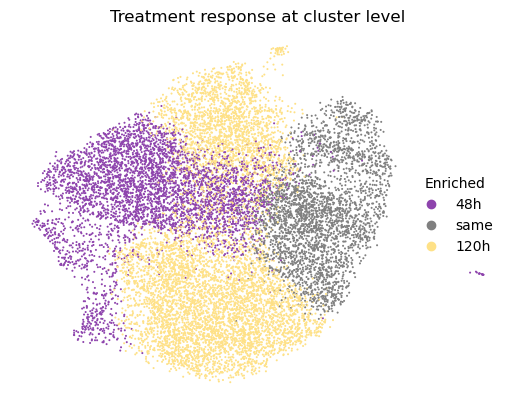

In [15]:
# Make UMAP of treatment response
ax = sc.pl.umap(adata, color=treatment_key, frameon=False, title="Treatment response at cluster level", show=False)
ax.legend(title='Enriched', loc='right', frameon=False)

In [16]:
# Import gene sets
print("Writing gene set details into anndata object...")
adata = utils.get_gene_sets(adata, verbose=False)

Writing gene set details into anndata object...


In [17]:
# Compute gene set scores
import utils_genelist as genelist
features = ['score_Lgr5', 'score_fetal']
for feature in features:
    genes = adata.uns['gene_sets'][adata.uns['gene_sets']['gene_set'] == feature]['gene']
    adata = genelist.compute_gene_score(adata, genes, score_name=feature,
                                        layer='log1p', verbose=False)

/tmp/ipykernel_3058665/116888430.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([feature_labels[f] for f in df['feature'].unique()])


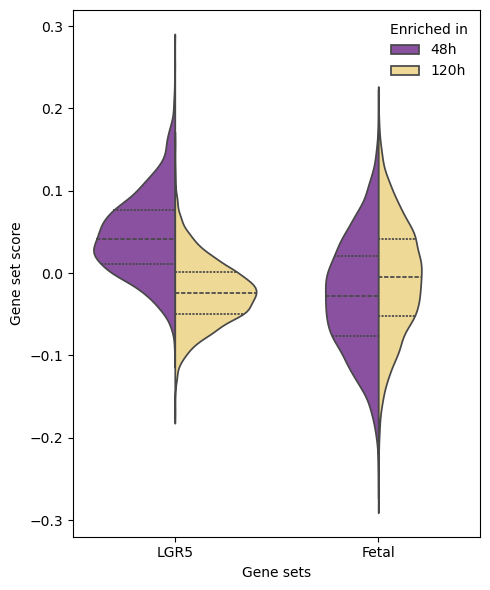

In [18]:
### Gene set expression across treatment response
feature_labels = {
    'score_fetal': 'Fetal',
    'score_Lgr5': 'LGR5',
}

# Extract data into DataFrame
df = adata.obs[[treatment_key]].copy()  # Copy the metadata into a DataFrame
for feature in features:        
    df[feature] = adata.obs_vector(feature, layer='normalized')
# To long format
df = df.melt(
    id_vars=[treatment_key], 
    value_vars=features, 
    var_name='feature', 
    value_name='value'
)

# Plot as violin plot
plt.figure(figsize=(5, 6))
ax = sns.violinplot(
    data=df, 
    x='feature', 
    y='value', 
    hue=treatment_key, 
    hue_order=['48h', '120h'],
    split=True, 
    palette=color_code[treatment_key]['colors'],
    fill=True, 
    inner='quart'
)
plt.xlabel('Gene sets')
plt.ylabel('Gene set score')
# Replace x-tick labels
ax.set_xticklabels([feature_labels[f] for f in df['feature'].unique()])
ax.legend(title='Enriched in', loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

In [19]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

rank_sum = []

# Test differential gene set score across treatment response
for score in features:
    x = df[(df['feature'] == score) & (df[treatment_key] == '120h')]['value']
    y = df[(df['feature'] == score) & (df[treatment_key] == '48h')]['value']
    # Perform rank sum test
    rank_stat, rank_p_value = mannwhitneyu(x, y, alternative='two-sided', )
    
    # Append results to rank_sum
    rank_sum.append({
        "gene_set": score,
        "median_cl_dn": y.median(),
        "median_cl_up": x.median(),
        "mean_cl_dn": y.mean(),
        "mean_cl_up": x.mean(),
        "rank_statistic": rank_stat,
        "rank_p_value": rank_p_value,
    })

# Convert to DataFrame
rank_sum_df = pd.DataFrame(rank_sum)

# Apply multiple testing correction to the p-values
p_values = rank_sum_df["rank_p_value"].values
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')  # FDR correction (Benjamini-Hochberg)
# Add corrected p-values to the DataFrame
rank_sum_df["rank_p_value_FDR(BH)"] = corrected_p_values
rank_sum_df.to_csv(f'../data_suppl/{accession}_Ext_Fig_07m_test.csv', index=False)
rank_sum_df

,gene_set,median_cl_dn,median_cl_up,mean_cl_dn,mean_cl_up,rank_statistic,rank_p_value,rank_p_value_FDR(BH)
0,score_Lgr5,0.041718,-0.024511,0.045263,-0.023676,3748553.0,0.000000e+00,0.000000e+00
1,score_fetal,-0.028105,-0.005353,-0.027703,-0.006066,16966552.0,1.806963e-57,1.806963e-57


### Reading palantir data object

In [5]:
import palantir

In [6]:
dir_data = '../data/palantir/'
files = os.listdir(dir_data)
files = [f for f in files if f.endswith('.h5ad')]
files

['Org_chemo_LM3_woCC_palantir_v00.h5ad',
 'HD4246_SG_0h-48h_palantir.h5ad',
 'HD4246_SG_48-120h_palantir.h5ad',
 'SG_0h_6h_24h_48h_woCC_res0.4_cl0-6_v01_palantir.h5ad',
 'Org_chemo_LM3_palantir.h5ad',
 'SG_48h_72h_120h_woCC_v02b_palantir.h5ad']

In [11]:
file = '../data/palantir/HD4246_SG_48-120h_palantir.h5ad'
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 13929 × 27594
    obs: 'sample_id', 'line', 'treatment', 'timepoint', 'replicate', 'library', 'leiden', 'batch', 'palantir_pseudotime', 'palantir_entropy'
    var: 'dispersions', 'dispersions_norm', 'gene_trends_clusters'
    uns: 'DM_EigenValues', 'leiden_colors', 'neighbors', 'palantir_start_state', 'palantir_terminal_states', 'palantir_waypoints', 'sample_id_colors', 'timepoint_colors', 'treatment_colors'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_pca', 'X_umap', 'branch_masks', 'palantir_fate_probabilities'
    varm: 'PCs', 'gene_trends_Term_DM3_min', 'gene_trends_Term_umap2_min'
    layers: 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

In [12]:
adata.uns['palantir_terminal_states']

{'cell_ids': array(['ATTGGCGCAGGATTAC-1-12', 'TATCGTAGTGAGGACT-1-2'], dtype=object),
 'state_names': array(['Term_umap2_min', 'Term_DM3_min'], dtype=object)}

In [13]:
# Pick branch color from color code
branches = ['Term_umap2_min', 'Term_DM3_min']
branch_color = {
    'Term_umap2_min':  '#737379',
    'Term_DM3_min': '#9d9da1',
}
# Mapping of interpretable branch names
branch_title = {
    "Term_umap2_min": "Main trajectory",
    "Term_DM3_min": "Side trajectory",
}

### Plotting palantir results

[2026-04-27 22:41:20,193] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,079) and rank = 1.0.
[2026-04-27 22:41:20,194] [INFO    ] Using covariance function Matern52(ls=0.8594485282897949).
[2026-04-27 22:41:20,212] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-04-27 22:41:22,371] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-04-27 22:41:22,947] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (1,452) and rank = 1.0.
[2026-04-27 22:41:22,949] [INFO    ] Using covariance function Matern52(ls=0.8594485282897949).
[2026-04-27 22:41:22,963] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-04-27 22:41:24,058] [INFO    ] Sigma interpreted as element-wise standard deviation.


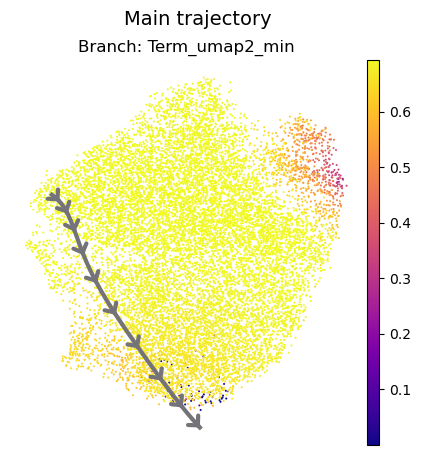

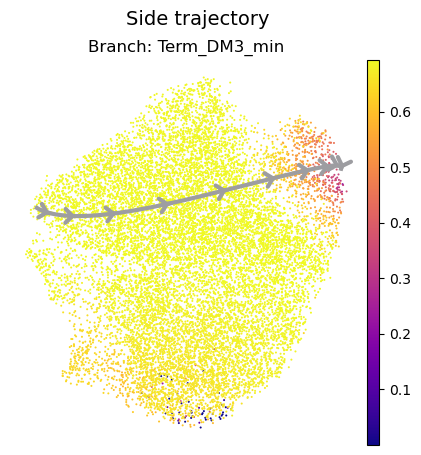

In [14]:
# Plot branches on UMAP colored by entropy
entropy_cmap = 'plasma'

for branch in branches:
    color = 'palantir_entropy'
    palantir.plot.plot_trajectory(
        adata,
        branch,
        cell_color="palantir_entropy",
        n_arrows=10,
        color=branch_color[branch],
        scanpy_kwargs=dict(cmap=entropy_cmap), 
        arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3),
        lw=3, 
        pseudotime_interval=(0, .9), 
    )
    fig = plt.gcf()
    fig.suptitle(branch_title[branch], fontsize=14)
    fig.show()

In [15]:
# Compute gene trends
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

Term_umap2_min
[2026-04-27 22:41:28,484] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,079) and rank = 1.0.
[2026-04-27 22:41:28,485] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-04-27 22:41:29,569] [INFO    ] Sigma interpreted as element-wise standard deviation.
Term_DM3_min
[2026-04-27 22:41:32,254] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (1,452) and rank = 1.0.
[2026-04-27 22:41:32,255] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-04-27 22:41:32,768] [INFO    ] Sigma interpreted as element-wise standard deviation.


In [16]:
# Extract gene expression along pseudotime
genes = ["TACSTD2", "LGR5"]

df_expr = pd.concat(
    {
        (gene, br): (
            adata.varm[f"gene_trends_{br}"]
            .loc[gene]
            .astype(float)
            .reset_index(drop=True)
        )
        for gene in genes
        for br in branches
    },
    axis=1
)

df_expr.index.name = "pseudotime_bin"
df_expr.head(2)

TACSTD2                        LGR5             
               Term_umap2_min Term_DM3_min Term_umap2_min Term_DM3_min
pseudotime_bin                                                        
0                    0.737753     0.508265       0.425576     0.438346
1                    0.739296     0.512501       0.424621     0.437236

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_gene_expression_from_df(
    df_expr,
    branches='Term_DM3_min',
    gene_1='TACSTD2',
    gene_2='LGR5',
    branch_linestyles=None,
    branch_to_cond=None,
    color_gene_1='green',
    color_gene_2='red',
    linewidth=4,
    scale_min_max=False,
    title=None,
    figsize=(8, 6),
):
    """
    Plot expression trends for two genes across one or multiple trajectories.

    Encoding:
    - color = gene
    - linestyle = branch
    """

    def _minmax_scale(x):
        x = np.asarray(x, dtype=float)
        xmin, xmax = np.nanmin(x), np.nanmax(x)
        if xmax > xmin:
            return (x - xmin) / (xmax - xmin)
        return np.zeros_like(x, dtype=float)

    if isinstance(branches, str):
        branches = [branches]

    if branch_to_cond is None:
        branch_to_cond = {br: br for br in branches}

    if branch_linestyles is None:
        default_styles = ['-', '--', ':', '-.']
        branch_linestyles = {
            br: default_styles[i % len(default_styles)]
            for i, br in enumerate(branches)
        }

    gene_colors = {
        gene_1: color_gene_1,
        gene_2: color_gene_2
    }

    fig, ax = plt.subplots(figsize=figsize)

    for br in branches:
        if (gene_1, br) not in df_expr:
            print(f"Warning: ({gene_1}, {br}) not found in df_expr. Skipping.")
            continue
        if (gene_2, br) not in df_expr:
            print(f"Warning: ({gene_2}, {br}) not found in df_expr. Skipping.")
            continue

        expr_1 = np.asarray(df_expr[(gene_1, br)], dtype=float)
        expr_2 = np.asarray(df_expr[(gene_2, br)], dtype=float)

        if scale_min_max:
            expr_1 = _minmax_scale(expr_1)
            expr_2 = _minmax_scale(expr_2)

        pseudotime_1 = np.arange(len(expr_1))
        pseudotime_2 = np.arange(len(expr_2))

        linestyle = branch_linestyles.get(br, '-')

        ax.plot(
            pseudotime_1, expr_1,
            color=gene_colors[gene_1],
            linewidth=linewidth,
            linestyle=linestyle
        )
        ax.plot(
            pseudotime_2, expr_2,
            color=gene_colors[gene_2],
            linewidth=linewidth,
            linestyle=linestyle
        )

    if title is None:
        if len(branches) == 1:
            title = f"Gene Expression Trends for {gene_1} and {gene_2}"
        else:
            title = f"Gene Expression Trends across Trajectories: {gene_1} and {gene_2}"

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Pseudotime", fontsize=14)
    ax.set_ylabel("Expression" if not scale_min_max else "Scaled expression", fontsize=14)

    if len(branches) == 1:
        gene_handles = [
            Line2D([0], [0], color=gene_colors[gene_1], lw=linewidth, linestyle='-', label=gene_1),
            Line2D([0], [0], color=gene_colors[gene_2], lw=linewidth, linestyle='-', label=gene_2)
        ]
        ax.legend(handles=gene_handles, title="Gene", frameon=False)
    else:
        gene_handles = [
            Line2D([0], [0], color=gene_colors[gene_1], lw=linewidth, linestyle='-', label=gene_1),
            Line2D([0], [0], color=gene_colors[gene_2], lw=linewidth, linestyle='-', label=gene_2)
        ]
        branch_handles = [
            Line2D([0], [0], color='black', lw=linewidth, linestyle=branch_linestyles[br], label=branch_to_cond.get(br, br))
            for br in branches
        ]

        leg1 = ax.legend(
            handles=gene_handles,
            title="Gene",
            frameon=False,
            loc='upper left',
            bbox_to_anchor=(1.02, 0.75),
            borderaxespad=0
        )
        ax.add_artist(leg1)

        ax.legend(
            handles=branch_handles,
            title="Trajectory",
            frameon=False,
            loc='upper left',
            bbox_to_anchor=(1.02, 0.3),
            borderaxespad=0
        )

    plt.tight_layout()
    plt.show()

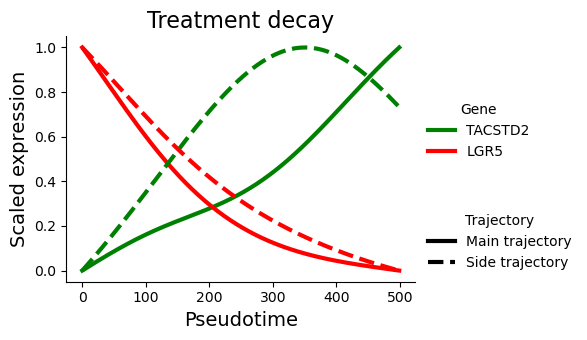

In [18]:
# Define the branches and their colors
branch_linestyles = {
    'Term_DM3_min': '--',
    'Term_umap2_min': '-'
}

# Define the branches and their colors
plot_gene_expression_from_df(
    df_expr,
    branches=branches,
    gene_1='TACSTD2',
    gene_2='LGR5',
    color_gene_1='green',
    color_gene_2='red',
    branch_linestyles=branch_linestyles,
    linewidth=3,
    branch_to_cond=branch_title,
    scale_min_max=True,
    title = "Treatment decay",
    figsize=(6, 3.5)
)

# Get data from arrayExpress: SG time course in vitro

In [3]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16843"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16843 in: ../data_arrayExpress/E-MTAB-16843
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16843
      Inferred 1 dataset representation: org (full prefix: HD4246_SG_org)
      Selected dataset for in-memory loading: org (full prefix: HD4246_SG_org)
[3/3] Preparing selected dataset.
      Loading selected dataset from disk: E-MTAB-16843/E-MTAB-16843_org.h5ad


AnnData object with n_obs × n_vars = 46906 × 24823
    obs: 'sample_id', 'library_id', 'drug', 'timepoint', 'treatment', 'batch'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

In [4]:
import decoupler as dc
dc.__version__

'2.0.6'

### Generate pseudobulks

In [5]:
### Read data
drugs = ['SG', 'UNADC']
adatas = {}

# Iterate over drugs and read corresponding data
for drug in drugs:
    adatas[drug] = adata[adata.obs['drug'] == drug].copy()
    print(f"Data for {drug} read successfully. Shape: {adatas[drug].shape}")

# Free up memory
del adata

Data for SG read successfully. Shape: (23788, 24823)
Data for UNADC read successfully. Shape: (23118, 24823)


Generating pseudobulks for treatment with drug: SG
(16, 24823)


/tmp/ipykernel_3746363/1944070408.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata.obs.groupby([sample_col, group_col]).size()


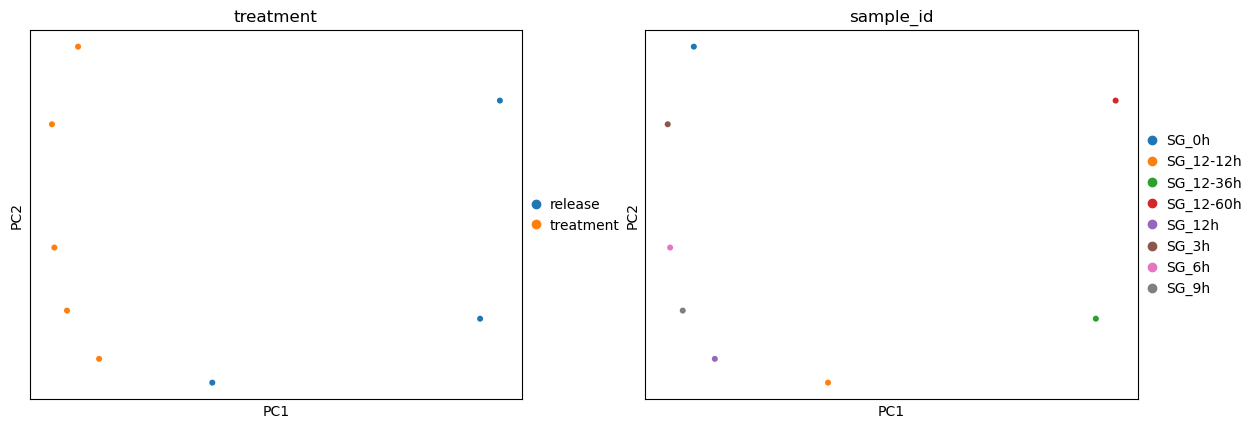

Generating pseudobulks for treatment with drug: UNADC
(16, 24823)


/tmp/ipykernel_3746363/1944070408.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata.obs.groupby([sample_col, group_col]).size()


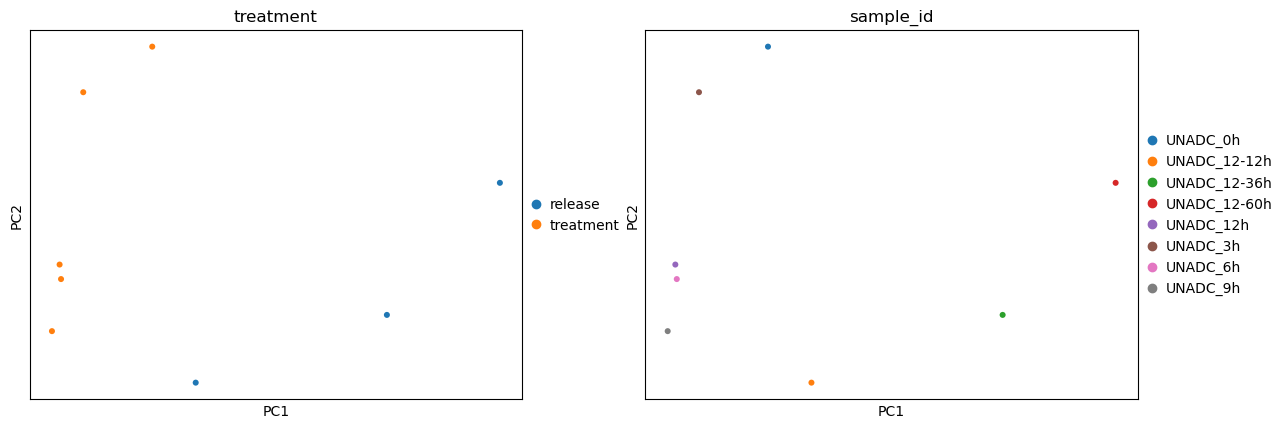

In [ ]:
# Generate pseudobulks
drugs = ['SG', 'UNADC']

# Define pseudobulk setup
sample_col = 'sample_id'
group_col = 'treatment'
min_cells = 10

pbulks = {}

# Iterate over drugs and generate pseudobulk for each drug
for drug in drugs:

    ### Subset dataset to drug of interest
    print(f"Generating pseudobulks for treatment with drug: {drug}")
    adata = adatas[drug]

    ### Get pseudo-bulk profile
    pdata = dc.pp.pseudobulk(
        adata,
        sample_col=sample_col,
        groups_col=group_col,
        layer='counts',
        mode='sum',
    )
    print(pdata.shape)
    
    ### Filter for minimum number of cells
    # Count cells in original single-cell AnnData
    cell_counts = adata.obs.groupby([sample_col, group_col]).size()
    # Keep only sample-group combinations with enough cells
    valid_combinations = set(cell_counts[cell_counts >= min_cells].index)
    # print(f"Valid samples: {valid_combinations}") ### tbc: remove line
    # Build tuples from pdata.obs
    pdata_combinations = list(zip(pdata.obs[sample_col], pdata.obs[group_col]))
    # Filter pdata
    pdata = pdata[[comb in valid_combinations for comb in pdata_combinations]].copy()

    ### Perform dimension reduction on pseudobulk profiles
    # Store raw counts in layers
    pdata.layers['counts'] = pdata.X.copy()
    # Normalize, scale and compute pca
    sc.pp.normalize_total(pdata, target_sum=1e4)
    sc.pp.log1p(pdata)
    sc.pp.scale(pdata, max_value=10)
    sc.tl.pca(pdata)
    # Return raw counts to X
    dc.pp.swap_layer(pdata, key='counts', inplace=True)

    ### Visualize data on PCA
    # Not part of manuscript
    sc.pl.pca(pdata, color=[group_col, sample_col], ncols=2, size=75)
    
    ### Filter by expression
    min_count = 10
    min_total_count = 15
    dc.pp.filter_by_expr(
        pdata, 
        group=sample_col, 
        min_count=min_count, 
        min_total_count=min_total_count
    )
    
    ### Stash in dictionary
    pbulks[drug] = pdata

    # Write to disk
    out_file = f'../data_suppl/{accession}_pbulk_{drug}.h5ad'
    pdata.write_h5ad(out_file)

### Get gene sets for enrichment testing

In [7]:
import utils_SG_org_timecourse as utils_spec
from utils_SG_org_timecourse import gene_set_selection

In [63]:
print("Writing gene set details into anndata object...")
import utils
nets = {}
for drug in drugs:
    adatas[drug] = utils.get_gene_sets(adatas[drug], verbose=False)
    nets[drug] = adatas[drug].uns['gene_sets']

# Simplify to one gene set collection if identical
if nets['SG'].equals(nets['UNADC']):
    print("Gene set collections are identical. Continue with one...")
    net = nets['SG']

Writing gene set details into anndata object...
Gene set collections are identical. Continue with one...


In [15]:
# Clear memory
del adatas

### DGEA based on pbulk

In [66]:
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [67]:
# DGEA parameters
design = 'treatment'
design_test = 'release'
design_ref = 'treatment'

# Results storage
dgea_results = {}

# Iterate over drugs and run DGEA through DESeq2: release vs on-treatment
for drug in drugs:
    print(f"Running DESeq2 for drug: {drug}")
    pdata = pbulks[drug]

    # Choose samples for comparison between on-treatment and release
    remove_sample = "0h"
    pdata = pdata[pdata.obs[sample_col] != remove_sample, :].copy()

    # Create DESeq2 object
    inference = DefaultInference(n_cpus=8)
    dds = DeseqDataSet(
        adata=pdata,
        design_factors=design,
        ref_level=[design, design_ref],
        refit_cooks=True,
        inference=inference,
    )

    # Dispersion and LFC estimation 
    dds.deseq2()

    # Replace design underscores with dashes for DeseqStats
    design = design.replace("_", "-")
    design_ref = design_ref.replace("_", "-")

    # Contrast between conditions
    stat_res = DeseqStats(
        dds,
        contrast=[design, design_test, design_ref],
        inference=inference,
    )
    # Compute and depict Wald test results
    stat_res.summary()

    # Extract results
    results_df = stat_res.results_df
    results_df.insert(0, 'contrast', f'{design_test}_vs_{design_ref}')
    print(f"Number of DE genes with padj < 0.05: {results_df[results_df['padj'] < 0.05].shape[0]}\n")
    dgea_results[drug] = results_df

Running DESeq2 for drug: SG


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.42 seconds.

Fitting dispersion trend curve...
... done in 12.91 seconds.

Fitting MAP dispersions...
... done in 3.33 seconds.

Fitting LFCs...
... done in 1.62 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.25 seconds.



Log2 fold change & Wald test p-value: treatment release vs treatment
               baseMean  log2FoldChange     lfcSE      stat        pvalue  \
feature                                                                     
FBXO2        312.387646        1.118691  0.205835  5.434882  5.483273e-08   
AC009630.2     7.597156       -0.966865  0.674415 -1.433634  1.516767e-01   
LINC02158     14.557185       -1.032909  0.907816 -1.137796  2.552058e-01   
AL121672.3     7.473252       -0.218389  0.570336 -0.382914  7.017839e-01   
PRCP        1001.590518        0.353493  0.092203  3.833867  1.261444e-04   
...                 ...             ...       ...       ...           ...   
SCRN2        755.300388        0.703653  0.137423  5.120354  3.049630e-07   
AP000695.1    10.149822        0.007687  0.646964  0.011881  9.905203e-01   
BCAS1        865.216760        1.928047  0.454405  4.243016  2.205357e-05   
UGGT1       1754.500269       -0.192272  0.062934 -3.055140  2.249558e-03   
TAPT1  

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.03 seconds.

Fitting dispersion trend curve...
... done in 12.78 seconds.

Fitting MAP dispersions...
... done in 2.63 seconds.

Fitting LFCs...
... done in 1.62 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: treatment release vs treatment
               baseMean  log2FoldChange     lfcSE      stat        pvalue  \
feature                                                                     
FBXO2        216.005468        0.595469  0.191425  3.110723  1.866301e-03   
AL121672.3     6.660033        0.657161  0.571922  1.149041  2.505390e-01   
PRCP         877.126101        0.265509  0.085354  3.110693  1.866487e-03   
GPAT3       2227.880230       -0.452547  0.075213 -6.016879  1.778121e-09   
ANK3        1057.368694        0.495951  0.141349  3.508686  4.503257e-04   
...                 ...             ...       ...       ...           ...   
SCRN2        658.597038        0.353969  0.094754  3.735686  1.872042e-04   
BCAS1        361.924795        0.307429  0.331085  0.928552  3.531211e-01   
UGGT1       1812.811369       -0.007837  0.049313 -0.158917  8.737344e-01   
ZNF785         3.908795       -1.207656  0.884603 -1.365195  1.721917e-01   
TAPT1  

... done in 1.03 seconds.



### Enrichment of custom gene sets

In [68]:
# Define section-specific functions

def get_anndata_from_file(data_path=None, filename=None,
                          df=None,
                          stat_key='stat',
                          feature_key='names'):
    """
    Read anndata object from file.
    
    Args:
        data_path: path to data file
        filename: name of data file
        
    Returns:
        adata: anndata object
    """

    # Test if input data is provided
    if df is None and not os.path.exists(os.path.join(data_path, filename)):
        raise ValueError("Input data not correctly defined. Provide dataframe or input file.")

    # Read data from file if required
    if df is None:
        if not os.path.exists(os.path.join(data_path, filename)):
            raise ValueError(f"File not found: {filename}")
        if filename.endswith(".h5ad"):
            adata = sc.read_h5ad(os.path.join(data_path, filename))
            if adata.raw is None:
                if 'normalized' in adata.layers.keys():
                    print("Set raw to normalized")
                    adata.raw = adata.layers['normalized'].copy()
        elif filename.endswith(".pkl"):
            df = pd.read_pickle(os.path.join(data_path, filename))
            # Convert to Anndata object
            adata = anndata.AnnData(df)
            adata.obs['contrast'] = df.index  # Adds the comparison labels as metadata in obs
            adata.var_names = df.T.index
            adata.raw = adata
        elif filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(data_path, filename))
            # Rename columns if applicable
            if stat_key not in df.columns and 'scores' in df.columns:
                print(f"Rename column 'scores' to {stat_key}")
                df.rename(columns={'scores': stat_key}, inplace=True)
        else:
            raise ValueError(f"File format not implemented: {filename}")

    ### Construct adata from DGEA result if needed
    print('Construct adata from DGEA results')
    if 'contrast' not in df.columns:
        if 'group' in df.columns:
            df['contrast'] = [f"{g}-vs-rest" for g in df['group']]
        else:
            df['contrast'] = 'test_vs_ref'
    elif 'group' in df.columns:
        df['contrast'] = [f"{g}-vs-all" for g in df['group']]
        
    # Turn into score matrix
    df_pivot = df.pivot(index='contrast', columns=feature_key, values=stat_key)
    adata = anndata.AnnData(
        X=df_pivot.values,
        obs=pd.DataFrame(index=df_pivot.index),
        var=pd.DataFrame(index=df_pivot.columns),
    )

    # Set nan to zero
    adata.X[np.isnan(adata.X)] = 0

    adata.raw = adata

    return adata


# Get df from enrichment results
def get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source'):
        
    ''' Turn anndata object acts into pandas DataFrame with activities and p-values.'''

    # Create data frame from acts.obsm['estimate']
    act_df = pd.DataFrame(acts.X, columns=acts.var_names, index=acts.obs_names)   
    act_df = act_df.reset_index().melt(id_vars=contrast, var_name='source', value_name='acts')

    # Create data frame from acts.obsm['padj']
    key = [key for key in acts.obsm.keys() if key.startswith('padj')][0]
    pval_df = pd.DataFrame(acts.obsm[key].values, columns=acts.var_names, index=acts.obs_names)
    pval_df = pval_df.reset_index().melt(id_vars=contrast, var_name='source', value_name='padj')

    # Merge df and pval_df
    df = pd.merge(act_df, pval_df, on=[contrast, name])
    return df

In [95]:
# Perform enrichment analysis on DGEA results
df_enrich = {}

for drug in drugs:
    print(f"Performing enrichment analysis for drug: {drug}")
    # Reformat input dataframe
    results_df = dgea_results[drug].copy()
    results_df['names'] = results_df.index

    # Get anndata object from DGEA results
    ad_dgea = get_anndata_from_file(
        df=results_df,
        stat_key = 'stat', 
        feature_key = 'names'
    )

    # Perform network check
    import utils_genelist as genelist
    net = genelist.pre_network_checks(
        net = net, 
        var_names = pbulks[drug].var_names, 
        source='gene_set' if 'gene_set' in net.columns else 'source', 
        target='gene' if 'gene' in net.columns else 'target', 
        weight='weight',
    )

    # Run ULM
    dc.mt.ulm(
        data = ad_dgea,
        net = net,
    )

    # Get activities from anndata
    acts = dc.pp.get_obsm(ad_dgea, key='score_ulm')


    # Get enrichment results in df format
    df = get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source')
    df = df.sort_values(by='acts', ascending=False)

    # Change to publication names ### To be added
    from utils_SG_org_timecourse import gs_names_for_pub
    df['source'] = df['source'].map(gs_names_for_pub)

    # Store in dictionary
    df_enrich[drug] = df

Performing enrichment analysis for drug: SG
Construct adata from DGEA results
Performing enrichment analysis for drug: UNADC
Construct adata from DGEA results


In [103]:
# Reformat and merge into single df
df = pd.DataFrame()
for drug, df_drug in df_enrich.items():
    df_drug = df_drug.copy()
    df_drug['drug'] = drug
    df = pd.concat([df, df_drug], ignore_index=True)

In [104]:
### Prepare for plotting
# Get -log10(padj) for dot size and acts for color
df['size'] = -np.log10(df['padj'])
df['color'] = df['acts']
df.sort_values(by='color', ascending=False, inplace=True, ignore_index=True)
df.to_csv(f'../data_suppl/{accession}_Ext_Fig_10p.csv', index=False)

# Add overall column for sorting
df['acts_SG'] = df.apply(lambda row: row['acts'] if row['drug'] == 'SG' else np.nan, axis=1)
df['acts_UNADC'] = df.apply(lambda row: row['acts'] if row['drug'] == 'UNADC' else np.nan, axis=1)
df['acts_combined'] = df.apply(lambda row: row['acts_SG'] if not np.isnan(row['acts_SG']) else row['acts_UNADC'], axis=1)
df.sort_values(by='acts_combined', ascending=False, inplace=True, ignore_index=True)

# Filter for significant terms (e.g., padj < 0.05)
df_sig = df[df['padj'] < 0.05]
print(f"Number of significant terms: {df_sig.shape[0]}")
df_sig.head(2)

Number of significant terms: 26


,contrast,source,acts,padj,drug,size,color,acts_SG,acts_UNADC,acts_combined
0,release_vs_treatment,coreHR (Cañellas-Socias et al.),9.313940,1.045151e-19,SG,18.980821,9.313940,9.313940,NaN,9.313940
1,release_vs_treatment,epiHR (Cañellas-Socias et al.),6.808269,4.680181e-11,SG,10.329737,6.808269,6.808269,NaN,6.808269


/tmp/ipykernel_3746363/799649004.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


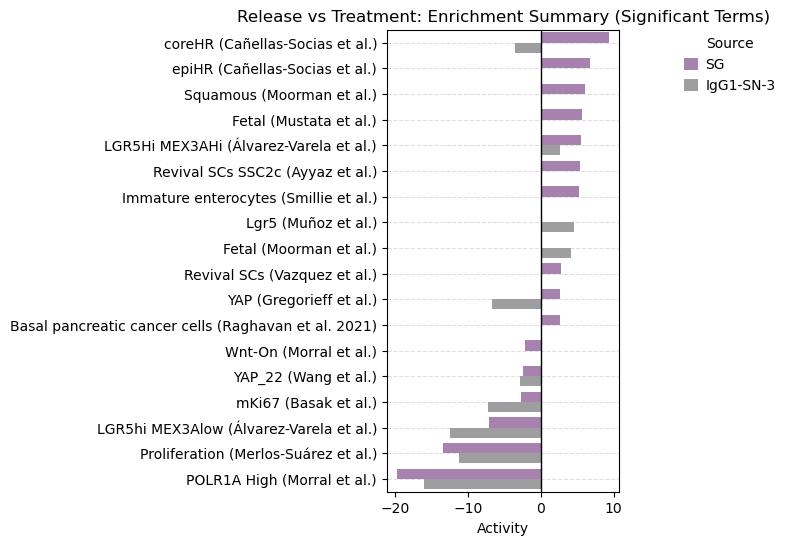

In [105]:
from utils_SG_org_timecourse import color_code

# Make bar graph instead of dot plot showing only significant terms
fig, ax = plt.subplots(figsize=(3, 6))
sns.barplot(data=df_sig, x='acts', y='source', hue='drug', orient='y', 
            palette=color_code['drug']['colors'], gap=0)

# Add horizontal grid for visibility
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.4) 
ax.axvline(0, color='black', linewidth=1)

plt.title('Release vs Treatment: Enrichment Summary (Significant Terms)')
plt.xlabel('Activity')
plt.ylabel('')
plt.legend(title='Source', bbox_to_anchor=(1.25, 1), loc='upper left')
# Rename UNADC to "IgG1-SN-3" in legend
handles, labels = ax.get_legend_handles_labels()
labels = ['IgG1-SN-3' if label == 'UNADC' else label for label in labels]
ax.legend(handles, labels, title='Source', bbox_to_anchor=(1.25, 1), loc='upper left')
fig.tight_layout()
fig.show()